Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Label counts:
label
0    154
1    159
Name: count, dtype: int64
Sensitive counts:
sensitive
0    230
1     83
Name: count, dtype: int64

=== Group stats (seed=0) ===
train | s=0 count=137  y=1 count=71  y=0 count=66
train | s=1 count=50  y=1 count=24  y=0 count=26
val | s=0 count=46  y=1 count=24  y=0 count=22
val | s=1 count=17  y=1 count=8  y=0 count=9
test | s=0 count=47  y=1 count=24  y=0 count=23
test | s=1 count=16  y=1 count=8  y=0 count=8
seed 0 | test_acc=0.794 | ΔSP=0.033 | ΔEO=0.333 | best_epoch=10
seed 1 | test_acc=0.746 | ΔSP=0.027 | ΔEO=0.042 | best_epoch=6
seed 2 | test_acc=0.635 | ΔSP=0.157 | ΔEO=0.167 | best_epoch=19
seed 3 | test_acc=0.714 | ΔSP=0.070 | ΔEO=0.125 | best_epoch=8
seed 4 | test_acc=0.714 | ΔSP=0.180 | ΔEO=0.208 | best_epoch=25
seed 5 | test_acc=0.603 | ΔSP=0.088 | ΔEO=0.167 | best_epoch=9
seed 6 | test_acc=0.825 | ΔSP=0.012 | Δ

,seed,best_epoch,train_acc,val_acc,test_acc,train_dsp,val_dsp,test_dsp,train_deo,val_deo,test_deo
0,0,10,0.716578,0.793651,0.793651,0.038540,0.112532,0.033245,0.066901,0.041667,0.333333
1,1,6,0.721925,0.793651,0.746032,0.032263,0.158245,0.026854,0.025822,0.458333,0.041667
2,2,19,0.796791,0.777778,0.634921,0.001752,0.234015,0.156915,0.030517,0.000000,0.166667
3,3,8,0.780749,0.761905,0.714286,0.101752,0.031969,0.070479,0.127934,0.083333,0.125000
4,4,25,0.812834,0.746032,0.714286,0.009343,0.023018,0.179521,0.165493,0.083333,0.208333
5,5,9,0.754011,0.873016,0.603175,0.042044,0.155585,0.088235,0.178404,0.083333,0.166667
6,6,10,0.770054,0.746032,0.825397,0.005547,0.066496,0.011968,0.108568,0.125000,0.166667
7,7,8,0.759358,0.793651,0.777778,0.087445,0.175532,0.181586,0.205986,0.125000,0.166667
8,8,14,0.791444,0.761905,0.666667,0.129343,0.007979,0.038363,0.206573,0.000000,0.041667
9,9,9,0.775401,0.730159,0.746032,0.023358,0.255755,0.135638,0.025822,0.250000,0.458333



=== Baseline (GCN) on NBA ===
Test Acc: 0.722 ± 0.071
ΔSP     : 0.092 ± 0.066
ΔEO     : 0.188 ± 0.126


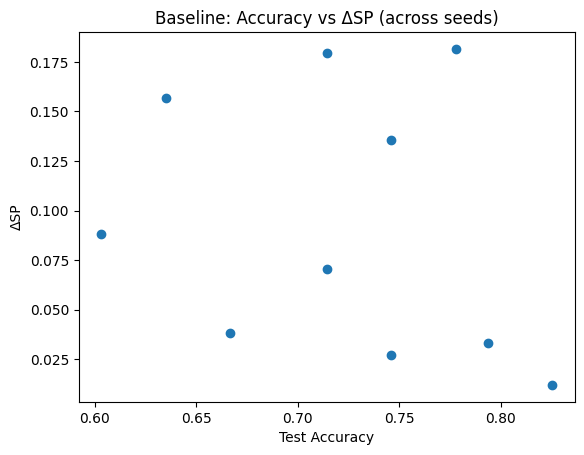

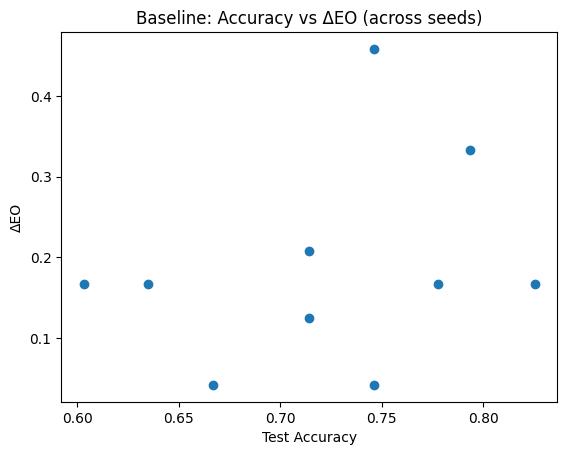


Saved: nba_gcn_baseline_results.csv


In [ ]:
# =========================
# 0) Install (Colab)
# =========================
%pip install -q torch torchvision torchaudio
%pip install -q torch-geometric
%pip install -q scikit-learn pandas numpy matplotlib

# =========================
# 1) Imports
# =========================
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

from google.colab import drive
drive.mount('/content/drive')

# -------------------------
# (Optional) Repro seed helper
# -------------------------
def set_global_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# =========================
# 2) Load & preprocess NBA dataset
# =========================
csv_path = "/content/drive/MyDrive/courses/network/NBA/dataset/nba.csv"
edge_path = "/content/drive/MyDrive/courses/network/NBA/dataset/nba_relationship.txt"

nodes = pd.read_csv(csv_path)

# Drop unknown labels
nodes["SALARY"] = pd.to_numeric(nodes["SALARY"], errors="coerce")
nodes = nodes[nodes["SALARY"].notna() & (nodes["SALARY"] != -1)].copy()

# Label: salary > 0 (keep same as your current logic)
nodes["label"] = (nodes["SALARY"] > 0).astype(int)

# Sensitive attribute: country (binary)
country = pd.to_numeric(nodes["country"], errors="coerce").fillna(0)
nodes["sensitive"] = (country > 0).astype(int)

feature_cols = [
    c for c in nodes.columns
    if c not in ["user_id", "SALARY", "country", "label", "sensitive"]
]

print("Label counts:")
print(nodes["label"].value_counts().sort_index())
print("Sensitive counts:")
print(nodes["sensitive"].value_counts().sort_index())

# Edges
edges = pd.read_csv(edge_path, sep="\t", names=["src", "dst"])

# =========================
# 3) Stratified split masks (stratify by (y, sensitive))
# =========================
def make_stratified_masks(y: torch.Tensor, s: torch.Tensor,
                          train_ratio=0.6, val_ratio=0.2, seed=0):
    y_np = y.cpu().numpy()
    s_np = s.cpu().numpy()
    strata = y_np * 2 + s_np  # 0..3

    idx_all = np.arange(len(y_np))

    # train vs temp
    sss1 = StratifiedShuffleSplit(n_splits=1, train_size=train_ratio, random_state=seed)
    train_idx, temp_idx = next(sss1.split(idx_all, strata))

    # val vs test from temp
    temp_strata = strata[temp_idx]
    val_size_rel = val_ratio / (1 - train_ratio)

    sss2 = StratifiedShuffleSplit(n_splits=1, train_size=val_size_rel, random_state=seed)
    val_rel, test_rel = next(sss2.split(temp_idx, temp_strata))

    val_idx = temp_idx[val_rel]
    test_idx = temp_idx[test_rel]

    n = len(y_np)
    train_mask = torch.zeros(n, dtype=torch.bool)
    val_mask = torch.zeros(n, dtype=torch.bool)
    test_mask = torch.zeros(n, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    return train_mask, val_mask, test_mask

def print_group_stats(y, s, mask, name):
    y_m = y[mask].cpu().numpy()
    s_m = s[mask].cpu().numpy()
    for sv in [0, 1]:
        idx = (s_m == sv)
        print(f"{name} | s={sv} count={idx.sum()}  y=1 count={(y_m[idx]==1).sum()}  y=0 count={(y_m[idx]==0).sum()}")

# =========================
# 4) Build PyG Data (train-only scaler, undirected graph)
# =========================
def build_data(nodes_df: pd.DataFrame, edges_df: pd.DataFrame,
               feature_cols, seed=0):
    y = torch.tensor(nodes_df["label"].values, dtype=torch.long)
    s = torch.tensor(nodes_df["sensitive"].values, dtype=torch.long)

    train_mask, val_mask, test_mask = make_stratified_masks(y, s, seed=seed)

    # Train-only scaler fit (avoid leakage)
    X_np = nodes_df[feature_cols].values
    scaler = StandardScaler()
    X_scaled = X_np.copy()

    train_idx = train_mask.numpy()
    X_scaled[train_idx] = scaler.fit_transform(X_np[train_idx])
    X_scaled[~train_idx] = scaler.transform(X_np[~train_idx])

    X = torch.tensor(X_scaled, dtype=torch.float)

    # Map user_id to 0..N-1
    id_map = {uid: i for i, uid in enumerate(nodes_df["user_id"].values)}

    src_list, dst_list = [], []
    for src, dst in zip(edges_df["src"], edges_df["dst"]):
        if src in id_map and dst in id_map:
            src_list.append(id_map[src])
            dst_list.append(id_map[dst])

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    # Make undirected
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

    data = Data(x=X, edge_index=edge_index, y=y)
    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask
    data.sensitive = s

    return data

# =========================
# 5) Model
# =========================
class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class SupervisedGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_dim=64, num_classes=2, dropout=0.5):
        super().__init__()
        self.encoder = GCNEncoder(in_channels, hidden_dim, dropout=dropout)
        self.classifier = torch.nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index):
        z = self.encoder(x, edge_index)
        return self.classifier(z)

# =========================
# 6) Metrics
# =========================
@torch.no_grad()
def fairness_metrics(y_true, y_pred, sensitive):
    """
    y_true, y_pred, sensitive are 1D tensors on the SAME MASKED subset.
    Returns:
      delta_sp = |P(ŷ=1|s=0) - P(ŷ=1|s=1)|
      delta_eo = |TPR(s=0) - TPR(s=1)|
    If a group has no samples / no positives, returns NaN for that component.
    """
    # rate of predicted positive in group
    def safe_mean(mask):
        return y_pred[mask].float().mean() if mask.any() else torch.tensor(float("nan"))

    p1_s0 = safe_mean(sensitive == 0)
    p1_s1 = safe_mean(sensitive == 1)

    # TPR in group (only on y=1)
    tpr_s0 = safe_mean((sensitive == 0) & (y_true == 1))
    tpr_s1 = safe_mean((sensitive == 1) & (y_true == 1))

    delta_sp = torch.abs(p1_s0 - p1_s1)
    delta_eo = torch.abs(tpr_s0 - tpr_s1)

    return float(delta_sp), float(delta_eo)

@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    acc = (pred[mask] == data.y[mask]).float().mean().item()
    dsp, deo = fairness_metrics(data.y[mask], pred[mask], data.sensitive[mask])
    return acc, dsp, deo

# =========================
# 7) Train one run (Early stopping on VAL only; test only once at best checkpoint)
# =========================
def train_one_run(data, seed=0, max_epochs=500, patience=50,
                  lr=0.01, weight_decay=5e-4, hidden_dim=64, dropout=0.5):
    set_global_seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data = data.to(device)

    model = SupervisedGCN(
        in_channels=data.num_features,
        hidden_dim=hidden_dim,
        num_classes=2,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.CrossEntropyLoss()

    best_state = None
    best_val_acc = -1.0
    best_epoch = 0
    bad = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()

        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])

        loss.backward()
        optimizer.step()

        val_acc, val_sp, val_eo = evaluate(model, data, data.val_mask)

        if val_acc > best_val_acc + 1e-4:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    # load best
    model.load_state_dict(best_state)

    train_acc, train_sp, train_eo = evaluate(model, data, data.train_mask)
    val_acc, val_sp, val_eo = evaluate(model, data, data.val_mask)
    test_acc, test_sp, test_eo = evaluate(model, data, data.test_mask)

    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "train_acc": train_acc, "val_acc": val_acc, "test_acc": test_acc,
        "train_dsp": train_sp, "val_dsp": val_sp, "test_dsp": test_sp,
        "train_deo": train_eo, "val_deo": val_eo, "test_deo": test_eo,
    }

# =========================
# 8) Run multi-seed baseline + summary(mean±std) + plots
# =========================
seeds = list(range(10))  # 10 seeds (you can change to 5 if you want)

results = []
for split_seed in seeds:
    data = build_data(nodes, edges, feature_cols, seed=split_seed)

    # (optional) sanity check once
    if split_seed == 0:
        print("\n=== Group stats (seed=0) ===")
        print_group_stats(data.y, data.sensitive, data.train_mask, "train")
        print_group_stats(data.y, data.sensitive, data.val_mask, "val")
        print_group_stats(data.y, data.sensitive, data.test_mask, "test")

    res = train_one_run(data, seed=split_seed)
    results.append(res)
    print(f"seed {split_seed} | test_acc={res['test_acc']:.3f} | ΔSP={res['test_dsp']:.3f} | ΔEO={res['test_deo']:.3f} | best_epoch={res['best_epoch']}")

df = pd.DataFrame(results)
display(df)

def mean_std(series):
    return float(series.mean()), float(series.std())

acc_mean, acc_std = mean_std(df["test_acc"])
dsp_mean, dsp_std = mean_std(df["test_dsp"])
deo_mean, deo_std = mean_std(df["test_deo"])

print("\n=== Baseline (GCN) on NBA ===")
print(f"Test Acc: {acc_mean:.3f} ± {acc_std:.3f}")
print(f"ΔSP     : {dsp_mean:.3f} ± {dsp_std:.3f}")
print(f"ΔEO     : {deo_mean:.3f} ± {deo_std:.3f}")

# fairness–accuracy plots across seeds
plt.figure()
plt.scatter(df["test_acc"], df["test_dsp"])
plt.xlabel("Test Accuracy")
plt.ylabel("ΔSP")
plt.title("Baseline: Accuracy vs ΔSP (across seeds)")
plt.show()

plt.figure()
plt.scatter(df["test_acc"], df["test_deo"])
plt.xlabel("Test Accuracy")
plt.ylabel("ΔEO")
plt.title("Baseline: Accuracy vs ΔEO (across seeds)")
plt.show()

# (optional) save results to csv
df.to_csv("nba_gcn_baseline_results.csv", index=False)
print("\nSaved: nba_gcn_baseline_results.csv")